In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import numpy as np
import pandas as pd

### Grid section

In [14]:
df_tess = pd.read_csv('TESS EBS Catalogue.csv', delimiter=',', header=0)
df_tess[0:20]

,tess_id,signal_id,date_added,date_modified,source,ra,dec,pmra,pmdec,Tmag,...,sec_width_pf,sec_depth_pf,sec_pos_pf,prim_width_2g,prim_depth_2g,prim_pos_2g,sec_width_2g,sec_depth_2g,sec_pos_2g,sectors
0,185259483,1,2020-07-27 20:19:32.475646,2021-09-16 17:36:17.538222,Light Curve File (LCF),175.108299,-6.102530,5.76498,-10.347300,10.9183,...,NaN,NaN,NaN,0.320144,0.218613,0.004219,NaN,NaN,NaN,"9,36"
1,307990280,1,2020-07-27 20:19:32.859401,2021-09-16 17:36:17.578490,Light Curve File (LCF),129.235983,-67.744751,-22.88000,-12.314500,9.4314,...,0.266834,0.023058,0.514608,NaN,NaN,NaN,NaN,NaN,NaN,"9,10,11"
2,387178621,1,2020-07-27 20:19:32.958864,2021-09-16 17:36:17.621185,Light Curve File (LCF),140.414052,-55.907677,-4.22192,4.224380,11.1447,...,NaN,NaN,NaN,0.140927,0.441052,0.000095,0.176579,0.071165,0.506365,"9,10"
3,300560295,1,2020-07-27 20:19:33.639446,2021-09-16 17:36:17.671033,Light Curve File (LCF),112.915987,-68.133213,-20.41370,9.187170,10.7757,...,0.004393,0.026034,0.500378,0.006209,0.029672,0.000426,0.006037,0.029204,0.500434,"1,2,3,4,5,6,7,8,9,11,12,13,27,28,29,30,31,32,3..."
4,318185328,1,2020-07-27 20:19:33.751141,2021-09-16 17:36:17.721127,Light Curve File (LCF),162.141798,-3.624495,51.80000,-44.010000,10.4100,...,NaN,NaN,NaN,0.362418,0.300310,0.003106,0.303053,0.243379,0.503066,"9,35"
5,363326796,1,2020-07-27 20:19:33.867800,2021-09-16 17:36:17.770838,Light Curve File (LCF),146.098197,-48.837311,-43.22060,17.829600,9.8353,...,NaN,NaN,NaN,0.028907,0.087055,0.999968,0.037838,0.006008,0.500015,9
6,73764693,1,2020-07-27 20:19:34.167556,2021-09-16 17:36:17.812587,Light Curve File (LCF),155.841228,-37.616640,-33.25940,-20.125600,11.7770,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,36"
7,31273263,1,2020-07-27 20:20:35.595865,2021-09-16 17:36:17.853771,Light Curve File (LCF),88.103691,-68.159554,5.41806,26.235000,10.7858,...,NaN,NaN,NaN,0.019304,0.220268,0.000019,NaN,NaN,NaN,"1,2,3,4,5,6,8,9,11,12,13,28,29,31,32,33,34,35,..."
8,279955276,1,2020-07-27 20:20:35.821409,2021-09-16 17:36:17.895853,Light Curve File (LCF),82.135090,-68.603760,2.06216,13.619500,10.5877,...,NaN,NaN,NaN,0.195957,0.099307,0.999772,0.109126,0.031915,0.500008,"1,2,3,4,5,6,7,9,10,12,13"
9,144167463,1,2020-07-27 20:20:36.107545,2021-09-16 17:36:17.962779,Light Curve File (LCF),176.974420,-9.063790,-6.53859,-0.126272,9.6606,...,0.240765,0.004844,0.480508,NaN,NaN,NaN,NaN,NaN,NaN,9


In [6]:
import sys
sys.path.append('../')
from Functions.queryGrid import *

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [7]:
ids = df_tess['tess_id'].to_list()
chunk_size = 500
results = []

for i in range(0, len(ids), chunk_size):
    chunk = ids[i:i+chunk_size]
    df = queryGaia(chunk, DR=3)
    results.append(df)
    print(f"Done {i}")
    
df_gaia = pd.concat(results, ignore_index=True)

Skipping 5 stars because Gaia ID is '--'
Done 0
Skipping 4 stars because Gaia ID is '--'
Done 500
Skipping 4 stars because Gaia ID is '--'
Done 1000


KeyboardInterrupt: 

In [ ]:
df_gaia = Gaia3ToJohnson(df_gaia)
df_gaia

,Gaia3_id,TIC_id,Gaia3_dist,Gaia3_parallax,Gaia3_G,Gaia3_T,bp_rp,ext,bp_rp_err,b_v,b_v_err
0,3459295238636660352,165458777,145.475419,6.874014,10.726010,NaN,0.927716,NaN,0.032709,0.805749,0.0659
1,3460989036299055104,165456443,215.785717,4.634227,9.417890,7138.135254,0.421197,0.0069,0.000977,0.357112,0.0659
2,3464532418676024064,157175641,124.547258,8.029081,9.273170,NaN,0.762967,NaN,0.041653,0.656056,0.0659
3,3467432208797826432,142262969,473.895681,2.110169,10.602425,6464.500000,0.640859,0.0669,0.000398,0.546475,0.0659
4,3471021663289103872,390554357,384.290372,2.602199,8.219930,9892.428711,0.108978,0.1443,0.001516,0.116540,0.0659
...,...,...,...,...,...,...,...,...,...,...,...
4542,4607233138071959936,10393493,577.244508,1.732368,12.497898,6423.139648,0.719270,0.0263,0.031549,0.616620,0.0659
4543,4608674288577507456,18269802,328.435406,3.044739,11.175815,5580.016113,0.856182,0.0006,0.015939,0.740659,0.0659
4544,4609102617076419456,116161302,1404.504409,0.711995,11.672544,NaN,0.588678,NaN,0.004757,0.500392,0.0659
4545,4609332376349201408,116163356,1335.743043,0.748647,12.212008,6428.233398,0.653093,0.0652,0.020396,0.557356,0.0659


In [ ]:
plt.rcParams.update({'font.size' : 18})

Median 0.7193603515625


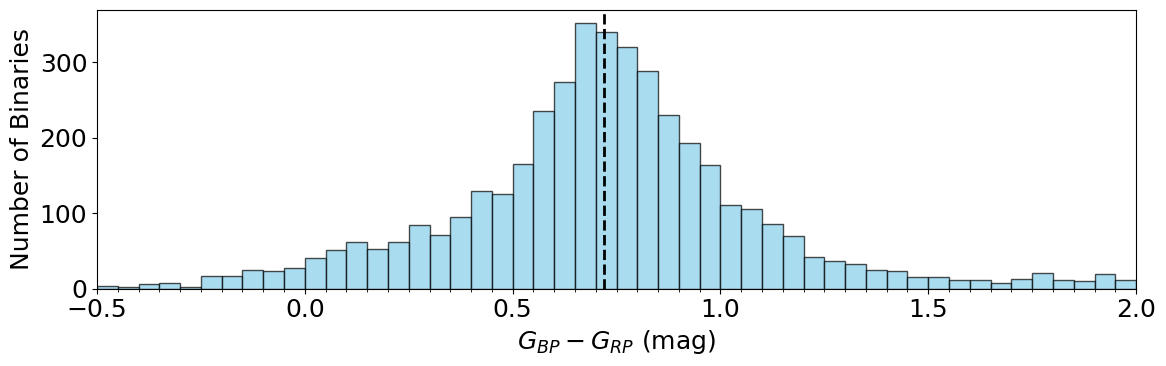

In [ ]:
# 1. Square Figure Size
plt.figure(figsize=(12, 4))

filtered_colors = df_gaia['bp_rp'][(df_gaia['bp_rp'] >= -0.5) & (df_gaia['bp_rp'] <= 2.0)].dropna()
median_color = filtered_colors.median()

bins = np.arange(-0.5, 2.01, 0.05,)

# 2. Histogram
plt.hist(filtered_colors, bins=bins, 
         color='skyblue', edgecolor='black', alpha=0.7)

# 3. Median Line
plt.axvline(median_color, color='black', linestyle='--', linewidth=2, 
            label=f'Median: {median_color:.2f}')

ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.FixedLocator(bins))

# 4. Final Square Formatting
plt.xlim(-0.5, 2.0)
# plt.gca().set_box_aspect(1) # Ensures the plot box is perfectly square

# plt.title('Stellar Population by Color ($BP - RP$)', fontsize=14)
plt.xlabel('$G_{BP} - G_{RP}$ (mag)')
plt.ylabel('Number of Binaries')
# plt.legend()
plt.tight_layout() # Ensures labels don't get cut off in square format

print(f"Median {median_color}")
plt.show()

Median: 255.39561546222666


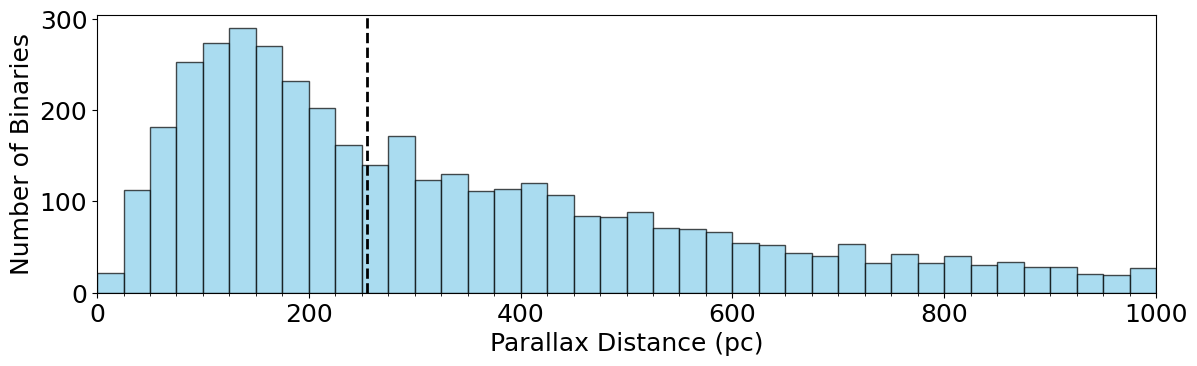

In [ ]:
# 1. Square Figure Size
plt.figure(figsize=(12, 4))
parallax = df_gaia['Gaia3_dist'][(df_gaia['Gaia3_dist'] >= 0) & (df_gaia['Gaia3_dist'] <= 1000)].dropna()
median_parallax = parallax.median()

bins = np.linspace(0, 1000, 41)

# 2. Histogram
plt.hist(parallax, bins=bins, 
         color='skyblue', edgecolor='black', alpha=0.7)


# 3. Median Line
plt.axvline(median_parallax, color='black', linestyle='--', linewidth=2, 
            label=f'Median: {median_parallax:.2f}')

ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.FixedLocator(bins))

# 4. Final Square Formatting
# plt.gca().set_box_aspect(1) # Ensures the plot box is perfectly square

# plt.title('Distribution of Eclipsing Binaries by Parallax Distance', fontsize=14)
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Number of Binaries')
# plt.legend()
plt.tight_layout() # Ensures labels don't get cut off in square format
plt.xlim(0, 1000)

print(f"Median: {median_parallax}")
plt.show()

Median 0.6167013949220338


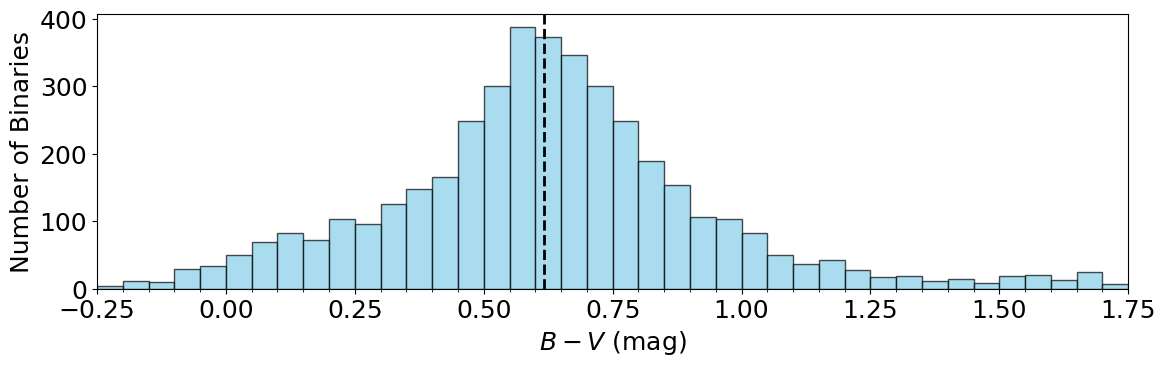

In [ ]:
# 1. Square Figure Size
plt.figure(figsize=(12, 4))

filtered_colors = df_gaia['b_v'][(df_gaia['bp_rp'] >= -0.5) & (df_gaia['bp_rp'] <= 2.0)].dropna()
median_color = filtered_colors.median()

bins = np.arange(-0.5, 2.01, 0.05,)

# 2. Histogram
plt.hist(filtered_colors, bins=bins, 
         color='skyblue', edgecolor='black', alpha=0.7)

# 3. Median Line
plt.axvline(median_color, color='black', linestyle='--', linewidth=2, 
            label=f'Median: {median_color:.2f}')

ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.FixedLocator(bins))

# 4. Final Square Formatting
plt.xlim(-0.25, 1.75)
# plt.gca().set_box_aspect(1) # Ensures the plot box is perfectly square

# plt.title('Stellar Population by Color ($BP - RP$)', fontsize=14)
plt.xlabel('$B - V$ (mag)')
plt.ylabel('Number of Binaries')
# plt.legend()
plt.tight_layout() # Ensures labels don't get cut off in square format

print(f"Median {median_color}")
plt.show()

### Match Filter

In [87]:
data1 = pd.read_csv('EBs Data.txt', sep=",", skipinitialspace=True)
data1['Target'] = data1['Target'].astype(str).str[4:].astype(int)

col_names = ['Index', 'TIC_Label', 'TIC_ID', 'Period', 'Width1', 'Width2', 'Depth1', 'Depth2']
df = pd.read_csv('EBs Data No Err.txt', 
                 sep=r'\s+', 
                 skiprows=1, # Skip the original header line
                 names=col_names)

# 2. Combine 'TIC' and the ID into the single 'Target' column
df['Target'] = df['TIC_Label'] + " " + df['TIC_ID'].astype(str)

# 3. Drop the temporary columns we used to build 'Target'
df = df.drop(columns=['TIC_Label', 'TIC_ID'])

# 4. Reorder to put 'Target' back where it belongs
data2 = df[['Index', 'Target', 'Period', 'Width1', 'Width2', 'Depth1', 'Depth2']]
data2['Target'] = data2['Target'].astype(str).str[4:].astype(int)

data = pd.concat([data1, data2], axis=0, ignore_index=True)

# Swap values so primary is always 1, secondary is always 2
mask = data['Depth1'] < data['Depth2']

data.loc[mask, ['Depth1', 'Depth2']] = data.loc[mask, ['Depth2', 'Depth1']].values
data.loc[mask, ['Width1', 'Width2']] = data.loc[mask, ['Width2', 'Width1']].values

data.loc[mask, ['A1 Error', 'A2 Error']] = data.loc[mask, ['A2 Error', 'A1 Error']].values
data.loc[mask, ['D1 Error', 'D2 Error']] = data.loc[mask, ['D2 Error', 'D1 Error']].values

data

,Index,Target,Period,P Error,Width1,D1 Error,Width2,D2 Error,Depth1,A1 Error,Depth2,A2 Error
0,0,364325969,0.419969,0.000505,0.290700,0.002186,0.271385,0.002067,0.280612,0.001074,0.252116,0.001046
1,1,140757590,0.418107,0.000505,0.290928,0.002647,0.289017,0.002844,0.232838,0.001196,0.204145,0.001194
2,2,177258700,0.687983,0.001717,0.279148,0.002482,0.295641,0.002888,0.274425,0.001238,0.240436,0.001202
3,3,349480507,3.124534,0.010000,0.088573,0.000387,0.088678,0.000264,0.381629,0.000552,0.381090,0.000510
4,4,33715938,2.876839,0.010000,0.072133,0.000853,0.070855,0.000567,0.364874,0.001583,0.349181,0.001420
...,...,...,...,...,...,...,...,...,...,...,...,...
2159,1130,158561566,6.812949,NaN,0.032429,NaN,0.031967,NaN,0.000604,NaN,0.000201,NaN
2160,1131,392536805,7.894265,NaN,0.023485,NaN,0.022775,NaN,0.024084,NaN,0.003673,NaN
2161,1132,267990226,3.262848,NaN,0.375773,NaN,0.376759,NaN,0.013395,NaN,0.013098,NaN
2162,1133,123042728,1.312936,NaN,0.244399,NaN,0.343688,NaN,0.113694,NaN,0.089580,NaN


In [88]:
df_match = data.copy()
df_match = df_match.merge(df_tess[['tess_id', 'period', 'prim_width_2g', 'prim_depth_2g', 'sec_width_2g', 'sec_depth_2g']], left_on='Target', right_on='tess_id', how='left')
df_match = df_match.dropna(subset=['period', 'prim_width_2g', 'prim_depth_2g', 'sec_width_2g', 'sec_depth_2g'])

# Data analysis
# df_match['Period_Diff'] = df_match['Period'] - df_match['period']
# df_match['Period_Diff_Norm'] = df_match['Period_Diff'] / df_match['P Error']

# df_match['Depth1_Diff'] = df_match['Depth1'] - df_match['prim_depth_2g']
# df_match['Depth1_Diff_Norm'] = df_match['Depth1_Diff'] / df_match['A1 Error']

# df_match['Depth2_Diff'] = df_match['Depth2'] - df_match['sec_depth_2g']
# df_match['Depth2_Diff_Norm'] = df_match['Depth2_Diff'] / df_match['A2 Error']

# df_match['Width1_Diff'] = df_match['Width1'] - df_match['prim_width_2g']
# df_match['Width1_Diff_Norm'] = df_match['Width1_Diff'] / df_match['D1 Error']

# df_match['Width2_Diff'] = df_match['Width2'] - df_match['sec_width_2g']
# df_match['Width2_Diff_Norm'] = df_match['Width2_Diff'] / df_match['D2 Error']

df_match

,Index,Target,Period,P Error,Width1,D1 Error,Width2,D2 Error,Depth1,A1 Error,Depth2,A2 Error,tess_id,period,prim_width_2g,prim_depth_2g,sec_width_2g,sec_depth_2g
0,0,364325969,0.419969,0.000505,0.290700,0.002186,0.271385,0.002067,0.280612,0.001074,0.252116,0.001046,364325969,0.419895,0.404296,0.333635,0.396830,0.325729
5,5,149629043,2.188053,0.005354,0.073452,0.000160,0.073825,0.000174,0.385046,0.000404,0.364962,0.000422,149629043,2.188110,0.086419,0.394678,0.085149,0.369970
6,6,294273900,0.472046,0.010000,0.279544,0.003138,0.277579,0.002377,0.253989,0.001076,0.230956,0.001078,294273900,0.472280,0.186501,0.216025,0.064593,0.198478
7,7,157175641,0.370090,0.010000,0.281426,0.002741,0.282454,0.002158,0.310746,0.001131,0.294896,0.001152,157175641,0.370238,0.344899,0.349881,0.326591,0.339119
8,8,382266319,0.344080,0.000303,0.293855,0.002117,0.280596,0.002382,0.348183,0.001312,0.311602,0.001361,382266319,0.344288,0.362038,0.428821,0.323087,0.384482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2156,1126,147625755,0.675967,NaN,0.255350,NaN,0.273567,NaN,0.672391,NaN,0.289330,NaN,147625755,0.675839,0.255333,0.680741,0.231701,0.268688
2158,1128,288391801,0.390943,NaN,0.367327,NaN,0.343863,NaN,0.309627,NaN,0.269111,NaN,288391801,0.390585,0.304709,0.263106,0.293490,0.233789
2161,1131,392536805,7.894265,NaN,0.023485,NaN,0.022775,NaN,0.024084,NaN,0.003673,NaN,392536805,8.409758,0.029595,0.065354,0.028839,0.051365
2163,1133,123042728,1.312936,NaN,0.244399,NaN,0.343688,NaN,0.113694,NaN,0.089580,NaN,123042728,1.312831,0.172638,0.093821,0.175657,0.067270


/tmp/ipykernel_5945/1975837496.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


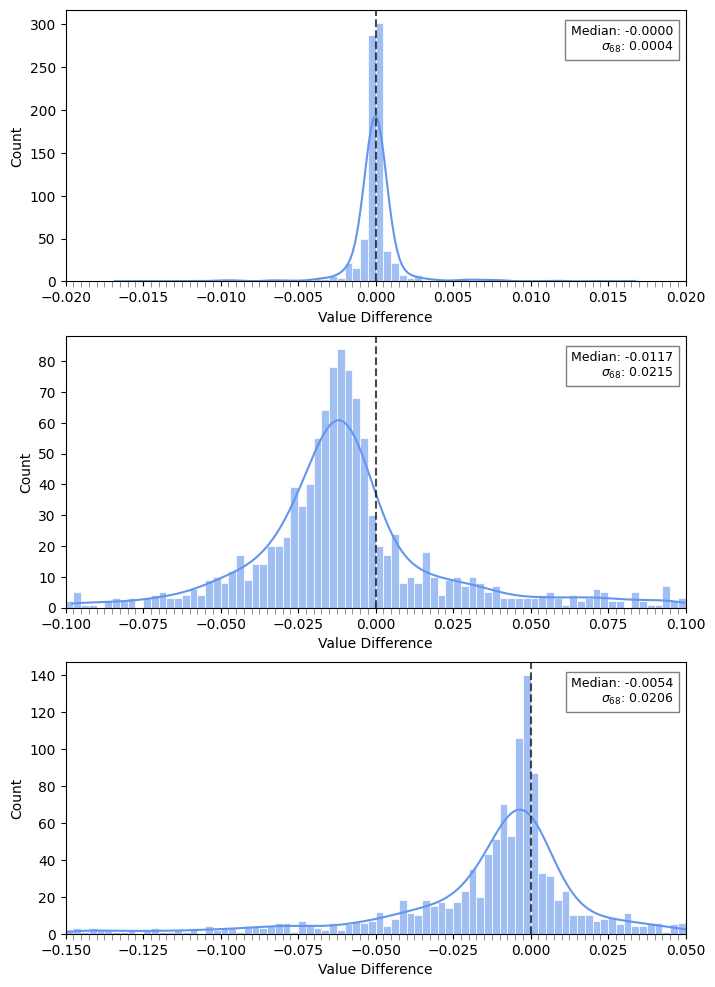

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# 1. Define the parameters to compare
comparisons = [
    ('Period', 'period', 'Period Difference (days)', (-0.01, 0.01)),
    ('Width1', 'prim_width_2g', 'Width Difference', (-0.1, 0.1)),
    ('Depth1', 'prim_depth_2g', 'Depth Difference', (-0.15, 0.05))
]

# 2. Setup the figure
fig, axes = plt.subplots(3, 1, figsize=(8, 12), gridspec_kw={'hspace': 0.2})

for i, (col1, col2, label, x_lims) in enumerate(comparisons):
    ax = axes[i]
    num_bins = 80
    
    # Data processing
    temp_df = df_match[[col1, col2]].apply(pd.to_numeric, errors='coerce').dropna()
    diff = temp_df[col1] - temp_df[col2]
    diff_filtered = diff[(diff >= x_lims[0]) & (diff <= x_lims[1])]

    # Plot
    sns.histplot(diff_filtered, bins=num_bins, binrange=x_lims, color='cornflowerblue', 
                 alpha=0.6, edgecolor='white', kde=True, ax=ax)
    
    # --- MINOR TICK LOGIC ---
    # Calculate the width of one bin to set the minor tick spacing
    bin_width = (x_lims[1] - x_lims[0]) / num_bins
    ax.xaxis.set_minor_locator(MultipleLocator(bin_width))
    
    # Optional: Make the ticks visible and adjust their length
    ax.tick_params(axis='x', which='minor', length=4, color='gray')
    # -------------------------

    # Stats and Aesthetics
    ax.axvline(0, color='black', linestyle='--', alpha=0.7)
    median = diff_filtered.median()
    sigma = (np.percentile(diff_filtered, 84) - np.percentile(diff_filtered, 16)) / 2
    
    ax.text(0.98, 0.85, f'Median: {median:.4f}\n' + r'$\sigma_{{68}}$' + f': {sigma:.4f}', 
                 transform=ax.transAxes, ha='right', fontsize=9, bbox=dict(facecolor='white', alpha=0.5))

    # ax.set_title(label, fontweight='bold')
    ax.set_xlim(x_lims)
    ax.set_xlabel('Value Difference')

plt.tight_layout()
plt.show()